In [33]:
import numpy as np

# Number of arms/options
num_arms = 5

# Number of rounds/trials
num_rounds = 1000

# Estimated average reward for each arm
estimated_rewards = np.zeros(num_arms)

# Number of times each arm has been pulled
arm_pulls = np.zeros(num_arms)

# UCB values for each arm
ucb_values = np.full(num_arms, np.inf)


# Display initialization
print("Estimated Rewards:", estimated_rewards)
print("Arm Pulls:", arm_pulls)
print("UCB Values:", ucb_values)

Estimated Rewards: [0. 0. 0. 0. 0.]
Arm Pulls: [0. 0. 0. 0. 0.]
UCB Values: [inf inf inf inf inf]


In [34]:
num_ads = 3

num_clicks = np.zeros(num_ads)
num_views = np.zeros(num_ads)

ucb_values = np.full(num_ads, np.inf)

print("Clicks:", num_clicks)
print("Views:", num_views)
print("UCB Values:", ucb_values)

Clicks: [0. 0. 0.]
Views: [0. 0. 0.]
UCB Values: [inf inf inf]


In [43]:
import numpy as np

# ============================================================
# UCB - Upper Confidence Bound
# ============================================================

# Number of arms
num_arms = 5

# Number of rounds
num_rounds = 1000

# Exploration constant
C = 2


# ============================================================
# INITIALIZATION
# ============================================================

# Estimated average reward for each arm
estimated_rewards = np.zeros(num_arms)

# Number of times each arm was selected
arm_pulls = np.zeros(num_arms)

# UCB values
ucb_values = np.full(num_arms, np.inf)

# Total reward
total_reward = 0

# Store selected arms
selected_arms = []


# ============================================================
# TRUE REWARD PROBABILITIES
# ============================================================

true_reward_probabilities = np.array([
    0.10,
    0.30,
    0.50,
    0.70,
    0.90
])


# ============================================================
# INITIAL VALUES
# ============================================================

print("Initial Estimated Rewards:")
print(estimated_rewards)

print("\nInitial Arm Pulls:")
print(arm_pulls)

print("\nInitial UCB Values:")
print(ucb_values)

print("\nTrue Reward Probabilities:")
print(true_reward_probabilities)


# ============================================================
# UCB ALGORITHM
# ============================================================

for current_round in range(1, num_rounds + 1):

    # --------------------------------------------------------
    # Calculate UCB for every arm
    # --------------------------------------------------------

    for arm in range(num_arms):

        if arm_pulls[arm] == 0:

            # Force exploration of unselected arms
            ucb_values[arm] = np.inf

        else:

            # Average reward
            average_reward = estimated_rewards[arm]

            # Exploration term
            exploration_term = C * np.sqrt(
                (2 * np.log(current_round))
                / arm_pulls[arm]
            )

            # UCB
            ucb_values[arm] = (
                average_reward
                + exploration_term
            )


    # --------------------------------------------------------
    # Select arm with highest UCB
    # --------------------------------------------------------

    selected_arm = np.argmax(ucb_values)

    selected_arms.append(selected_arm)


    # --------------------------------------------------------
    # Generate reward
    # --------------------------------------------------------

    reward = np.random.binomial(
        1,
        true_reward_probabilities[selected_arm]
    )


    # --------------------------------------------------------
    # Update number of pulls
    # --------------------------------------------------------

    arm_pulls[selected_arm] += 1


    # --------------------------------------------------------
    # Update total reward
    # --------------------------------------------------------

    total_reward += reward


    # --------------------------------------------------------
    # Update average reward
    # --------------------------------------------------------

    estimated_rewards[selected_arm] = (
        estimated_rewards[selected_arm]
        +
        (
            reward
            - estimated_rewards[selected_arm]
        )
        / arm_pulls[selected_arm]
    )


    # --------------------------------------------------------
    # Print first 10 rounds only
    # --------------------------------------------------------

    if current_round <= 10:

        print("\n================================")
        print("Round:", current_round)
        print("================================")

        print("UCB Values:")
        print(np.round(ucb_values, 3))

        print("Selected Arm:", selected_arm)

        print("Reward:", reward)

        print("Arm Pulls:")
        print(arm_pulls)

        print("Estimated Rewards:")
        print(np.round(estimated_rewards, 3))


# ============================================================
# FINAL RESULTS
# ============================================================

print("\n\n========================================")
print("FINAL RESULTS")
print("========================================")

print("\nTotal Reward:")
print(total_reward)


print("\nArm Pulls:")
print(arm_pulls.astype(int))


print("\nEstimated Rewards:")

for arm in range(num_arms):

    print(
        "Arm",
        arm,
        "->",
        np.round(estimated_rewards[arm], 3)
    )


print("\nTrue Reward Probabilities:")

for arm in range(num_arms):

    print(
        "Arm",
        arm,
        "->",
        true_reward_probabilities[arm]
    )


# ============================================================
# BEST ESTIMATED ARM
# ============================================================

best_arm = np.argmax(estimated_rewards)

print("\n========================================")
print("BEST ESTIMATED ARM")
print("========================================")

print("Arm:", best_arm)

print(
    "Estimated Reward:",
    np.round(estimated_rewards[best_arm], 3)
)

Initial Estimated Rewards:
[0. 0. 0. 0. 0.]

Initial Arm Pulls:
[0. 0. 0. 0. 0.]

Initial UCB Values:
[inf inf inf inf inf]

True Reward Probabilities:
[0.1 0.3 0.5 0.7 0.9]

Round: 1
UCB Values:
[inf inf inf inf inf]
Selected Arm: 0
Reward: 0
Arm Pulls:
[1. 0. 0. 0. 0.]
Estimated Rewards:
[0. 0. 0. 0. 0.]

Round: 2
UCB Values:
[2.355   inf   inf   inf   inf]
Selected Arm: 1
Reward: 0
Arm Pulls:
[1. 1. 0. 0. 0.]
Estimated Rewards:
[0. 0. 0. 0. 0.]

Round: 3
UCB Values:
[2.965 2.965   inf   inf   inf]
Selected Arm: 2
Reward: 1
Arm Pulls:
[1. 1. 1. 0. 0.]
Estimated Rewards:
[0. 0. 1. 0. 0.]

Round: 4
UCB Values:
[3.33 3.33 4.33  inf  inf]
Selected Arm: 3
Reward: 1
Arm Pulls:
[1. 1. 1. 1. 0.]
Estimated Rewards:
[0. 0. 1. 1. 0.]

Round: 5
UCB Values:
[3.588 3.588 4.588 4.588   inf]
Selected Arm: 4
Reward: 1
Arm Pulls:
[1. 1. 1. 1. 1.]
Estimated Rewards:
[0. 0. 1. 1. 1.]

Round: 6
UCB Values:
[3.786 3.786 4.786 4.786 4.786]
Selected Arm: 2
Reward: 0
Arm Pulls:
[1. 1. 2. 1. 1.]
Estimated Rew

In [45]:
import numpy as np


def ucb(ad_rewards, num_rounds):
    """
    Upper Confidence Bound (UCB) algorithm.

    ad_rewards:
        Rewards available for each ad in each round.

    num_rounds:
        Number of rounds to run.
    """

    num_ads = len(ad_rewards)

    # Number of times each ad has been selected
    ad_selections = np.zeros(num_ads)

    # Total reward obtained from each ad
    ad_rewards_sum = np.zeros(num_ads)

    # Store selected ad at every round
    selected_ads = []

    for t in range(1, num_rounds + 1):

        ucb_values = []

        # Calculate UCB for every ad
        for i in range(num_ads):

            if ad_selections[i] > 0:

                # Average reward
                avg_reward = (
                    ad_rewards_sum[i] / ad_selections[i]
                )

                # Exploration/confidence term
                confidence = np.sqrt(
                    (2 * np.log(t)) / ad_selections[i]
                )

                # UCB
                ucb_value = avg_reward + confidence

                ucb_values.append(ucb_value)

            else:
                # Never selected → encourage exploration
                ucb_values.append(np.inf)

        # Select ad with highest UCB
        selected_ad = np.argmax(ucb_values)

        # Store selected ad
        selected_ads.append(selected_ad)

        # Get reward for selected ad
        reward = ad_rewards[selected_ad][t - 1]

        # Update selection count
        ad_selections[selected_ad] += 1

        # Update total reward
        ad_rewards_sum[selected_ad] += reward

        # Print information
        print("\nRound:", t)
        print("UCB Values:", ucb_values)
        print("Selected Ad:", selected_ad)
        print("Reward:", reward)

    return selected_ads


# --------------------------------------------------
# DATA
# --------------------------------------------------

ad_rewards = [
    [1, 0, 1, 1, 0, 1, 0, 1, 1, 0],
    [0, 1, 0, 1, 0, 0, 1, 0, 1, 0],
    [1, 1, 1, 0, 1, 1, 1, 1, 0, 1]
]

num_rounds = 10


# --------------------------------------------------
# FUNCTION CALL
# --------------------------------------------------

selected_ads = ucb(ad_rewards, num_rounds)


# --------------------------------------------------
# FINAL RESULT
# --------------------------------------------------

print("\n==============================")
print("Final Selected Ads")
print("==============================")

print(selected_ads)


Round: 1
UCB Values: [inf, inf, inf]
Selected Ad: 0
Reward: 1

Round: 2
UCB Values: [np.float64(2.177410022515475), inf, inf]
Selected Ad: 1
Reward: 1

Round: 3
UCB Values: [np.float64(2.4823038073675114), np.float64(2.4823038073675114), inf]
Selected Ad: 2
Reward: 1

Round: 4
UCB Values: [np.float64(2.6651092223153956), np.float64(2.6651092223153956), np.float64(2.6651092223153956)]
Selected Ad: 0
Reward: 1

Round: 5
UCB Values: [np.float64(2.26863624117952), np.float64(2.7941225779941012), np.float64(2.7941225779941012)]
Selected Ad: 1
Reward: 0

Round: 6
UCB Values: [np.float64(2.33856619904585), np.float64(1.8385661990458504), np.float64(2.8930184728248456)]
Selected Ad: 2
Reward: 1

Round: 7
UCB Values: [np.float64(2.3949588341794583), np.float64(1.8949588341794583), np.float64(2.3949588341794583)]
Selected Ad: 0
Reward: 0

Round: 8
UCB Values: [np.float64(1.8440766891821414), np.float64(1.942026886600883), np.float64(2.4420268866008827)]
Selected Ad: 2
Reward: 1

Round: 9
UCB Va

In [47]:
print(round)
print(type(round))

9
<class 'int'>


FINAL RESULTS

Total Reward:
733

Arm Pulls:
Arm 0 -> 46 times
Arm 1 -> 63 times
Arm 2 -> 113 times
Arm 3 -> 236 times
Arm 4 -> 542 times

Estimated Rewards:
Arm 0 -> 0.109
Arm 1 -> 0.27
Arm 2 -> 0.504
Arm 3 -> 0.725
Arm 4 -> 0.891

True Reward Probabilities:
Arm 0 -> 0.1
Arm 1 -> 0.3
Arm 2 -> 0.5
Arm 3 -> 0.7
Arm 4 -> 0.9


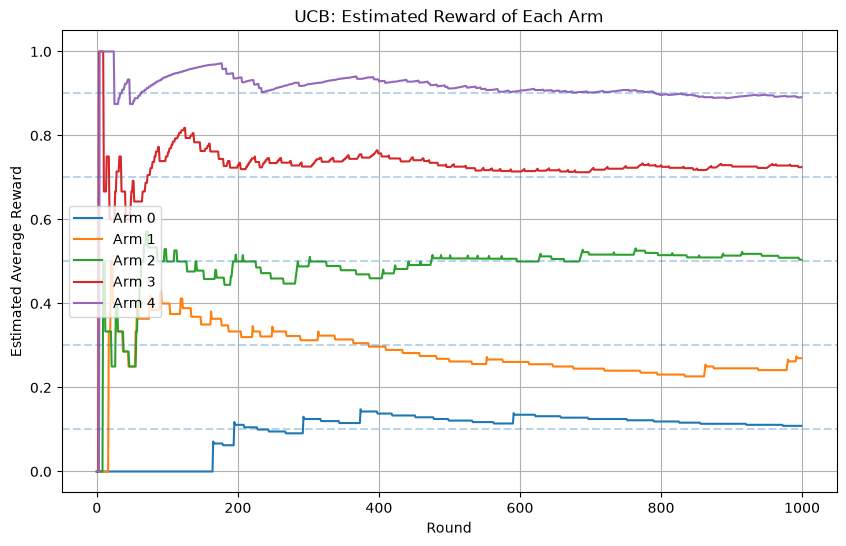

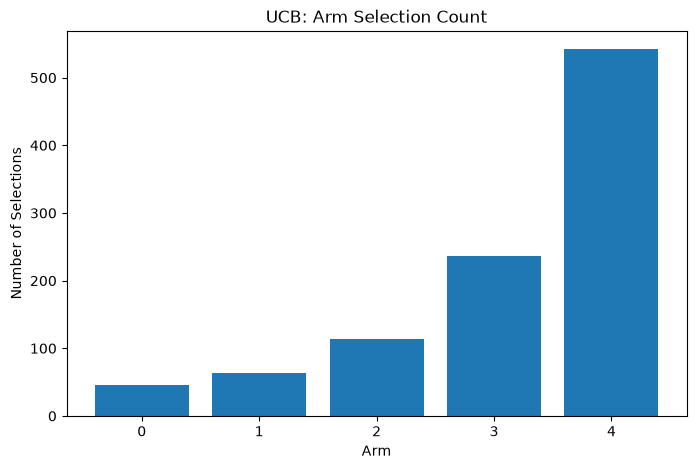

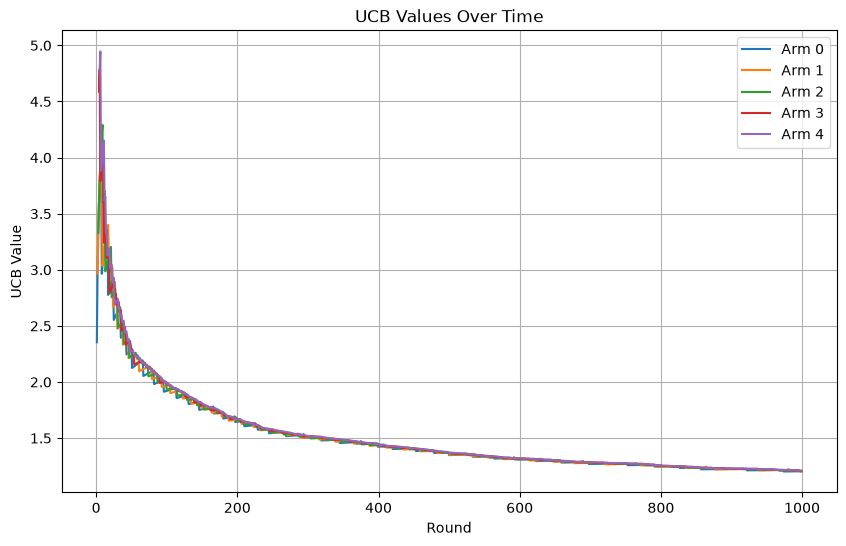

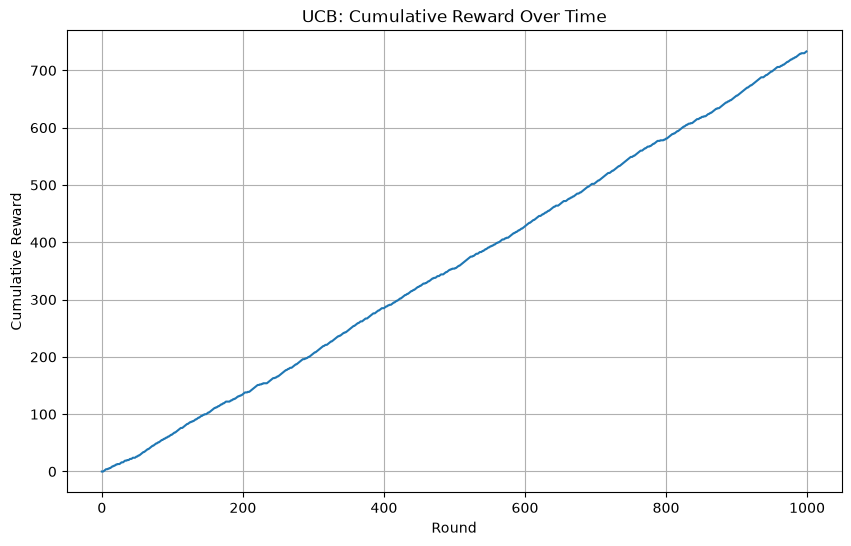

In [51]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. PARAMETERS
# ============================================================

num_arms = 5
num_rounds = 1000
C = 2


# ============================================================
# 2. TRUE REWARD PROBABILITIES
# ============================================================

true_reward_probabilities = np.array([
    0.10,
    0.30,
    0.50,
    0.70,
    0.90
])


# ============================================================
# 3. INITIALIZATION
# ============================================================

# Estimated average reward of each arm
estimated_rewards = np.zeros(num_arms)

# Number of times each arm is selected
arm_pulls = np.zeros(num_arms)

# UCB values
ucb_values = np.full(num_arms, np.inf)

# Total reward
total_reward = 0

# Store selected arms
selected_arms = []


# ============================================================
# 4. HISTORY FOR VISUALIZATION
# ============================================================

estimated_rewards_history = []
ucb_history = []
pulls_history = []
reward_history = []


# ============================================================
# 5. UCB ALGORITHM
# ============================================================

for current_round in range(1, num_rounds + 1):

    # --------------------------------------------------------
    # Calculate UCB for every arm
    # --------------------------------------------------------

    for arm in range(num_arms):

        if arm_pulls[arm] == 0:

            # Force exploration
            ucb_values[arm] = np.inf

        else:

            # Exploitation
            average_reward = estimated_rewards[arm]

            # Exploration
            exploration_term = C * np.sqrt(
                (2 * np.log(current_round))
                / arm_pulls[arm]
            )

            # UCB
            ucb_values[arm] = (
                average_reward +
                exploration_term
            )


    # --------------------------------------------------------
    # Select arm with highest UCB
    # --------------------------------------------------------

    selected_arm = np.argmax(ucb_values)

    selected_arms.append(selected_arm)


    # --------------------------------------------------------
    # Generate reward
    # --------------------------------------------------------

    reward = np.random.binomial(
        1,
        true_reward_probabilities[selected_arm]
    )


    # --------------------------------------------------------
    # Update values
    # --------------------------------------------------------

    arm_pulls[selected_arm] += 1

    total_reward += reward

    # Update average reward
    estimated_rewards[selected_arm] = (
        estimated_rewards[selected_arm]
        +
        (
            reward -
            estimated_rewards[selected_arm]
        )
        / arm_pulls[selected_arm]
    )


    # --------------------------------------------------------
    # SAVE HISTORY
    # --------------------------------------------------------

    estimated_rewards_history.append(
        estimated_rewards.copy()
    )

    ucb_history.append(
        ucb_values.copy()
    )

    pulls_history.append(
        arm_pulls.copy()
    )

    reward_history.append(reward)


# ============================================================
# 6. CONVERT HISTORY TO NUMPY ARRAYS
# ============================================================

estimated_rewards_history = np.array(
    estimated_rewards_history
)

ucb_history = np.array(
    ucb_history
)

pulls_history = np.array(
    pulls_history
)

reward_history = np.array(
    reward_history
)


# ============================================================
# 7. FINAL RESULTS
# ============================================================

print("======================================")
print("FINAL RESULTS")
print("======================================")

print("\nTotal Reward:")
print(total_reward)

print("\nArm Pulls:")

for arm in range(num_arms):
    print(
        "Arm",
        arm,
        "->",
        int(arm_pulls[arm]),
        "times"
    )

print("\nEstimated Rewards:")

for arm in range(num_arms):
    print(
        "Arm",
        arm,
        "->",
        np.round(estimated_rewards[arm], 3)
    )

print("\nTrue Reward Probabilities:")

for arm in range(num_arms):
    print(
        "Arm",
        arm,
        "->",
        true_reward_probabilities[arm]
    )


# ============================================================
# 8. VISUALIZATION 1
# ESTIMATED REWARD OVER TIME
# ============================================================

plt.figure(figsize=(10, 6))

for arm in range(num_arms):

    plt.plot(
        estimated_rewards_history[:, arm],
        label=f"Arm {arm}"
    )

# True probabilities as dashed lines
for arm in range(num_arms):

    plt.axhline(
        true_reward_probabilities[arm],
        linestyle="--",
        alpha=0.3
    )

plt.xlabel("Round")
plt.ylabel("Estimated Average Reward")
plt.title("UCB: Estimated Reward of Each Arm")
plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 9. VISUALIZATION 2
# NUMBER OF TIMES EACH ARM WAS SELECTED
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    range(num_arms),
    arm_pulls
)

plt.xlabel("Arm")
plt.ylabel("Number of Selections")
plt.title("UCB: Arm Selection Count")
plt.xticks(range(num_arms))

plt.show()


# ============================================================
# 10. VISUALIZATION 3
# UCB VALUES OVER TIME
# ============================================================

plt.figure(figsize=(10, 6))

for arm in range(num_arms):

    plt.plot(
        ucb_history[:, arm],
        label=f"Arm {arm}"
    )

plt.xlabel("Round")
plt.ylabel("UCB Value")
plt.title("UCB Values Over Time")
plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 11. VISUALIZATION 4
# CUMULATIVE REWARD
# ============================================================

cumulative_reward = np.cumsum(reward_history)

plt.figure(figsize=(10, 6))

plt.plot(
    cumulative_reward
)

plt.xlabel("Round")
plt.ylabel("Cumulative Reward")
plt.title("UCB: Cumulative Reward Over Time")
plt.grid(True)

plt.show()

UCB FINAL RESULTS

Ad Selection Frequency:
Ad 1: 103
Ad 2: 171
Ad 3: 92
Ad 4: 634

Total Clicks:
Ad 1: 18
Ad 2: 58
Ad 3: 12
Ad 4: 388

Click Through Rate (CTR):
Ad 1: 0.175
Ad 2: 0.339
Ad 3: 0.13
Ad 4: 0.612


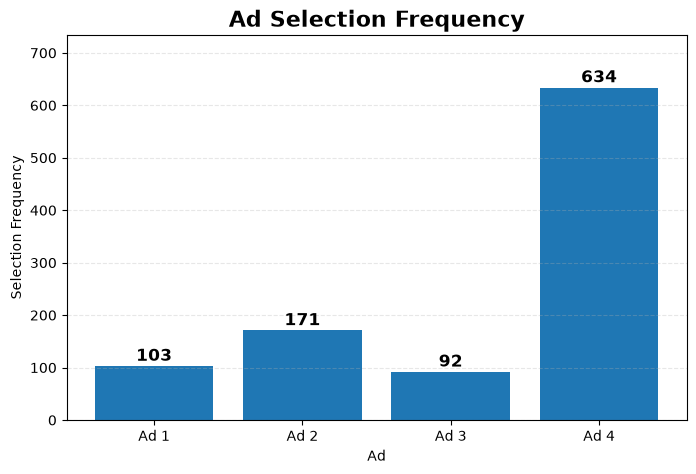

In [53]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# UCB (Upper Confidence Bound) - Ad Selection
# ============================================================

# Number of ads
num_ads = 4

# Number of rounds
num_rounds = 1000

# Exploration constant
C = 2


# ============================================================
# TRUE CLICK PROBABILITY OF EACH AD
# ============================================================

# These are hidden probabilities.
# UCB does not know them initially.

true_click_probability = np.array([
    0.20,   # Ad 1
    0.40,   # Ad 2
    0.10,   # Ad 3
    0.60    # Ad 4
])


# ============================================================
# INITIALIZATION
# ============================================================

# Number of times each ad is selected
num_views = np.zeros(num_ads)

# Number of clicks received by each ad
num_clicks = np.zeros(num_ads)

# UCB values
ucb_values = np.full(num_ads, np.inf)

# Store selected ads
selected_ads = []

# Store reward history
reward_history = []


# ============================================================
# UCB ALGORITHM
# ============================================================

for current_round in range(1, num_rounds + 1):

    # --------------------------------------------------------
    # Calculate UCB for each ad
    # --------------------------------------------------------

    for ad in range(num_ads):

        if num_views[ad] == 0:

            # Encourage exploration
            ucb_values[ad] = np.inf

        else:

            # Average reward / CTR
            average_reward = (
                num_clicks[ad] / num_views[ad]
            )

            # Exploration term
            exploration_term = C * np.sqrt(
                (2 * np.log(current_round))
                / num_views[ad]
            )

            # UCB formula
            ucb_values[ad] = (
                average_reward
                + exploration_term
            )


    # --------------------------------------------------------
    # Select ad having highest UCB
    # --------------------------------------------------------

    selected_ad = np.argmax(ucb_values)

    selected_ads.append(selected_ad)


    # --------------------------------------------------------
    # Simulate user click
    # --------------------------------------------------------

    click = np.random.binomial(
        1,
        true_click_probability[selected_ad]
    )

    reward_history.append(click)


    # --------------------------------------------------------
    # Update views and clicks
    # --------------------------------------------------------

    num_views[selected_ad] += 1

    num_clicks[selected_ad] += click


# ============================================================
# FINAL RESULTS
# ============================================================

print("======================================")
print("UCB FINAL RESULTS")
print("======================================")

print("\nAd Selection Frequency:")

for ad in range(num_ads):

    print(
        f"Ad {ad + 1}: {int(num_views[ad])}"
    )


print("\nTotal Clicks:")

for ad in range(num_ads):

    print(
        f"Ad {ad + 1}: {int(num_clicks[ad])}"
    )


print("\nClick Through Rate (CTR):")

for ad in range(num_ads):

    ctr = num_clicks[ad] / num_views[ad]

    print(
        f"Ad {ad + 1}: {np.round(ctr, 3)}"
    )


# ============================================================
# VISUALIZATION
# Ad Selection Frequency
# ============================================================

ads = [
    "Ad 1",
    "Ad 2",
    "Ad 3",
    "Ad 4"
]

selection_frequency = num_views.astype(int)


plt.figure(figsize=(8, 5))

bars = plt.bar(
    ads,
    selection_frequency
)


# Add values on top of bars
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 10,
        str(int(height)),
        ha="center",
        fontsize=12,
        fontweight="bold"
    )


plt.title(
    "Ad Selection Frequency",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Ad")
plt.ylabel("Selection Frequency")

plt.ylim(
    0,
    max(selection_frequency) + 100
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.show()